#### M4W Series

* [Table of Contents](M4WTOC.ipynb)
* <a href="https://colab.research.google.com/github/4dsolutions/m4w/blob/main/ProductLog.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>
* [![nbviewer](https://raw.githubusercontent.com/jupyter/design/master/logos/Badges/nbviewer_badge.svg)](https://nbviewer.org/github/4dsolutions/m4w/blob/main/ProductLog.ipynb)

# PRODUCT LOG FUNCTION

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55159982328/in/dateposted/" title="Screen Shot 2026-03-21 at 7.02.33 AM"><img src="https://live.staticflickr.com/65535/55159982328_99732c9bc1.jpg" width="500" height="281" alt="Screen Shot 2026-03-21 at 7.02.33 AM"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

So you've heard of the Log function, which comes in bases. It tells you how high to raise a base to get its input number, if that's even possible.

Like, how high must I raise a base of 10 to get 100?  Obviously 2. Log(100, base=10) == 2.

But what's this W function associated with the name Lambert, as in Lambert-W function?

Where might we find it in Python-verse, either in the Standard Library or 3rd Party?

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55159968968/in/dateposted/" title="Probing for Lambert-W Function in Python-verse"><img src="https://live.staticflickr.com/65535/55159968968_bae3cb2109.jpg" width="500" height="483" alt="Probing for Lambert-W Function in Python-verse"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

So right away I'm wondering what `sympy` has to offer, as that's a package we use a lot around here.  

But I'll check into that later (see Part 2 below), as I don't wanna lose my train of thought, or those of my readers.  

Lets not get lost right away.  The `scipy` version will do.

In [1]:
from scipy.special import lambertw  # ooo, it's special
import numpy as np

In [2]:
val = lambertw(1.0)
val  # verify we get the advertised result

(0.5671432904097838+0j)

Complex number type output, interesting...

OK, now that we're "armed and dangerous" so to speak, what might we do with our new W function? 

We could rename it first of all, or make a new name.

In [3]:
W = lambertw

In [4]:
W(1.0)

(0.5671432904097838+0j)

Now I'm gonna share a YouTube that walks us through a solution to a specific math problem wherein the W function comes in handy.

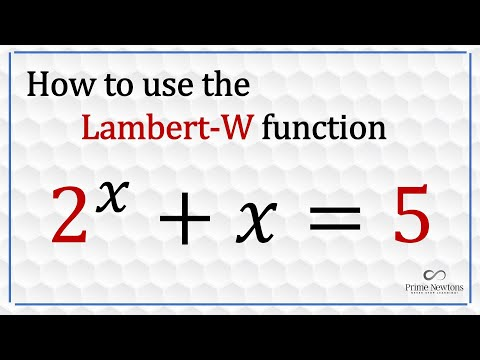

In [5]:
from IPython.display import YouTubeVideo
YouTubeVideo("mJwfpcXwYRU")  # another good vid at the bottom

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55159812686/in/photostream/" title="Screen Shot 2026-03-21 at 7.05.15 AM"><img src="https://live.staticflickr.com/65535/55159812686_cf4641d8d7.jpg" width="500" height="281" alt="Screen Shot 2026-03-21 at 7.05.15 AM"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

If you're viewing this Notebook in its Github repo, directly, then chances are you won't see any playable YouTube thumbnails.

Do you know about nbviewer?

You may end up wanting to checkout a copy of this repo, and leaving it untouched so you can easily pull down any future changes without merge issues.

Then, if you wanna fork locally, copy the clone.

You may also copy (fork) in the cloud.

In [6]:
np.e

2.718281828459045

In [7]:
# test W
def test(blah):
    var = blah * np.e ** blah
    return W(var) # do we get blah back?

In [8]:
test(10)

(10+0j)

In [9]:
assert test(10) == 10

In [10]:
for blah in (14.4, 9, 100, 33):  # the domain of W bears further research (see bottom picture)
    assert test(blah) == blah    # no objections your honor

Alright then!  It looks like we're in business!

After a lot of algebra, our math teacher manages to express the unknown quantity x in terms of the W function.

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55160087049/in/dateposted/" title="Screen Shot 2026-03-21 at 7.20.04 AM"><img src="https://live.staticflickr.com/65535/55160087049_e80d8eda2a.jpg" width="500" height="281" alt="Screen Shot 2026-03-21 at 7.20.04 AM"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

Lets check the result:

In [11]:
#? np.log  # remove initial # to get a readout on np.log

In numpy, log is natural log:

From the docs:  The natural logarithm `log` is the inverse of the exponential function,
so that `log(exp(x)) = x`. The natural logarithm is logarithm in base
`e`.

In [12]:
x = 5 - W(32 * np.log(2))/np.log(2)
x

(1.7156207332755864+0j)

In [13]:
2**x + x

(5+0j)

Yep!

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55158960287/in/dateposted/" title="Screen Shot 2026-03-21 at 7.30.14 AM"><img src="https://live.staticflickr.com/65535/55158960287_7ca35006d5_o.png" width="677" height="279" alt="Screen Shot 2026-03-21 at 7.30.14 AM"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

### Part 2: A Solution Using sympy

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55164868575/in/dateposted/" title="Product Log in Sympy"><img src="https://live.staticflickr.com/65535/55164868575_19d22e0e0b.jpg" width="500" height="397" alt="Product Log in Sympy"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

In [14]:
from sympy import LambertW, symbols, Symbol, solve, ln, S
x = symbols('x')
expr = LambertW(x)

In [15]:
expr

LambertW(x)

AI helped me write the following:

In [16]:
# Define the equation: 2**x + x = 5
# For solve, the equation should be in the form expr = 0
equation = 2**x + x - 5

# Solve the equation for x
solution = solve(equation, x)

# Print the solution
print(f"The solution for x is: {solution}")

# To verify, you can also substitute the solution back into the equation
# or numerically evaluate it.
# Let's evaluate the solution numerically
if solution:
    numerical_solution = solution[0].evalf(50)
    print(f"Numerical value of x: {numerical_solution}")

    # Check the original equation with the numerical solution
    check_value = 2**numerical_solution + numerical_solution
    print(f"Checking original equation: 2**x + x = {check_value} (should be 5)")

# Let's see the structure of the SymPy LambertW function output for comparison
# SymPy's LambertW might implicitly use W_0 for positive arguments.
# For expressions like W(32*ln(2)), it refers to the principal branch W_0.

The solution for x is: [(-LambertW(log(4294967296)) + log(32))/log(2)]
Numerical value of x: 1.7156207332755861693809164282101154053492015424027
Checking original equation: 2**x + x = 5.0000000000000000000000000000000000000000000000000 (should be 5)


<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55164494796/in/photostream/" title="More about Lambert-W in sympy"><img src="https://live.staticflickr.com/65535/55164494796_701e444c8e.jpg" width="452" height="500" alt="More about Lambert-W in sympy"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

The math teacher's solution:

In [17]:
-LambertW(32*ln(2))/ln(2) + 5

-LambertW(32*log(2))/log(2) + 5

That's $LaTex$ output.

$$
\left( -\frac{\text{LambertW}(32 \ln(2))}{\ln(2)} + 5 \right)
$$

In [18]:
(-LambertW(32*ln(2))/ln(2) + 5).evalf(50)

1.7156207332755861693809164282101154053492015424027

In [19]:
val = (-LambertW(32*ln(2))/ln(2) + 5).evalf()
2 ** val + val

5.00000000000000

sympy's solution:

$$
\frac{-\text{LambertW}(\ln(4294967296)) + \ln(32)}{\ln(2)}
$$

In [20]:
((-LambertW(ln(4294967296)) + ln(32))/ln(2)).evalf(50) # same number

1.7156207332755861693809164282101154053492015424027

Let's ask Google Gemini to show us why these two expressions are equal.

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55167956641/in/dateposted/" title="Google Gemini"><img src="https://live.staticflickr.com/65535/55167956641_1145ee2fdc_z.jpg" width="595" height="640" alt="Google Gemini"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

Gemini even recognizes the original context of the answer, and finds its way back to our original YouTube.

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55168122258/in/photostream/" title="Screen Shot 2026-03-25 at 9.07.27 AM"><img src="https://live.staticflickr.com/65535/55168122258_07ee98576e_z.jpg" width="640" height="263" alt="Screen Shot 2026-03-25 at 9.07.27 AM"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

[Link-Back from edu-sig](https://mail.python.org/archives/list/edu-sig@python.org/message/CZHV4G7FHQJPWN7TR64573GI2K753YX4/)

Another good vid:

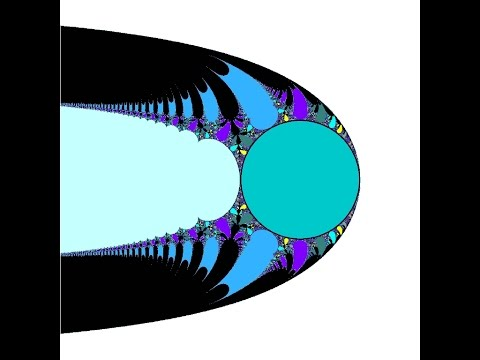

In [21]:
YouTubeVideo("cMZ_blqKKZU") 